In [3]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 14.2 MB/s  0:00:00a 0:00:01m eta 0:00:01

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [50]:
!pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [51]:
import spacy
import os
import re
import pandas as pd
from collections import Counter

pattern = r'(?<!e\.g)(?<!i\.e)(?:\.|\?)(?=\s|$)'
nlp = spacy.load("en_core_web_sm")

In [33]:
# Single Test Example

with open("../_books/2026-02-22-humbug.md", "r") as f:
    lines = f.read().splitlines()
    sentences = [sentence.strip() for line in lines for sentence in re.split(pattern,line)]

sentence_counter = Counter()
pos_counter = Counter()
for sentence in sentences:
    doc = nlp(sentence)
    print(sentence)
    sentence_pos = []
    for token in doc:
        sentence_pos.append(token.pos_)
        pos_counter[token.pos_] += 1
    print(" ".join(sentence_pos))
    sentence_counter[" ".join(sentence_pos)] += 1
    print("-"*30)

---
PUNCT
------------------------------
date:             2026-02-22
NOUN PUNCT SPACE NUM PUNCT NUM SYM NUM
------------------------------
description:  >-
NOUN PUNCT SPACE X PUNCT
------------------------------
A review of humbug & bs
DET NOUN ADP PROPN CCONJ PROPN
------------------------------
title: >-
NOUN PUNCT X PUNCT
------------------------------
Humbug & Bullshit
PROPN CCONJ PROPN
------------------------------
layout:           style
PROPN PUNCT SPACE NOUN
------------------------------
name: >-
NOUN PUNCT X PUNCT
------------------------------
Humbug & Bullshit
PROPN CCONJ PROPN
------------------------------
---
PUNCT
------------------------------


------------------------------
# Humbug & Bullshit
PROPN PROPN CCONJ PROPN
------------------------------


------------------------------
> "HUMBUG: deceptive misrepresentation, short of lying, especially by pretentious word or deed, of somebody's own thoughts, feelings, or attitudes."
X PUNCT PROPN PUNCT ADJ NOUN PUNCT ADJ 

In [34]:
sentence_counter.most_common(10)

[('', 29),
 ('PUNCT', 3),
 ('NOUN PUNCT X PUNCT', 2),
 ('PROPN CCONJ PROPN', 2),
 ('NOUN PUNCT SPACE NUM PUNCT NUM SYM NUM', 1),
 ('NOUN PUNCT SPACE X PUNCT', 1),
 ('DET NOUN ADP PROPN CCONJ PROPN', 1),
 ('PROPN PUNCT SPACE NOUN', 1),
 ('PROPN PROPN CCONJ PROPN', 1),
 ('X PUNCT PROPN PUNCT ADJ NOUN PUNCT ADJ ADP VERB PUNCT ADV ADP ADJ NOUN CCONJ NOUN PUNCT ADP PRON PART ADJ NOUN PUNCT NOUN PUNCT CCONJ NOUN PUNCT PUNCT',
  1)]

In [35]:
pos_counter.most_common(10)

[('NOUN', 160),
 ('PUNCT', 110),
 ('ADP', 88),
 ('VERB', 83),
 ('ADJ', 70),
 ('PRON', 66),
 ('DET', 59),
 ('AUX', 45),
 ('CCONJ', 39),
 ('ADV', 33)]

In [42]:
# Full run
dirs = ["/_books", "/_fun", "/_life", "/_work"]

sentence_counter = Counter()
pos_counter = Counter()

for path in dirs:
    for file in os.listdir(".." + path):
        if not (file.endswith(".md")): continue
        with open(".." + path + "/" + file, "r") as f:
                print(file)
                lines = f.read().splitlines()
                sentences = [sentence.strip() for line in lines for sentence in re.split(pattern,line)]
                for sentence in sentences:
                    doc = nlp(sentence)
                    sentence_pos = []
                    for token in doc:
                        sentence_pos.append(token.pos_)
                        pos_counter[token.pos_] += 1
                    sentence_counter[" ".join(sentence_pos)] += 1

2024-07-30-et-al.md
2024-08-18-fuck-your-feelings.md
2024-05-18-living-high.md
2024-07-19-what-time-is-this-place.md
2025-01-01-democratizing-innovation.md
2024-07-21-jojo.md
2025-06-30-vibecoding.md
2025-11-21-being.md
2024-06-01-the-art-of-listening.md
2024-07-17-homo-ludens.md
2024-10-19-loss.md
2025-02-22-fifth-discipline.md
2025-10-11-heideigger.md
*2024-08-24-pedagogy-of-the-opressed.md
*2024-10-19-on-earth.md
2024-08-21-analytical-readings.md
2024-10-26-absent-body.md
2024-12-27-postman.md
2026-02-22-humbug.md
2024-05-25-mans-search-for-meaning.md
2024-06-26-ways-of-seeing.md
2025-05-12-hbs.md
2024-05-21-random-walk-down-ws.md
2024-08-17-the-presentation-of-self.md
2025-02-25-worlds-in-plain-sight.md
2024-07-10-mind-self.md
2025-09-14-katabasis.md
2024-07-13-rounds.md
2025-04-09-typography.md
2025-04-13-photography.md
2024-08-30-guilty-gear-strive.md
*2025-10-20-smiling.md
2025-03-07-eternal-sunshine.md
2025-11-11.statemottos.md
2025-05-26.tv.md
2024-08-13-kind-words-2.md
2025-0

In [45]:
sentence_counter.most_common(20)

[('', 3271),
 ('PUNCT', 278),
 ('NOUN PUNCT X PUNCT', 200),
 ('NOUN PUNCT SPACE X PUNCT', 97),
 ('X PROPN X', 96),
 ('NUM', 94),
 ('PROPN PUNCT SPACE NOUN', 90),
 ('NOUN PUNCT SPACE NUM SYM NUM SYM NUM', 66),
 ('X X X', 61),
 ('SYM NOUN NOUN', 60),
 ('PROPN PUNCT SPACE VERB', 41),
 ('NOUN', 34),
 ('PROPN PROPN', 33),
 ('PUNCT NUM PUNCT', 32),
 ('SYM SYM SYM NOUN NUM', 26),
 ('SYM NOUN SYM NOUN NUM', 26),
 ('PROPN', 24),
 ('NOUN PUNCT SPACE NUM PUNCT NUM SYM NUM', 23),
 ('SYM NOUN PROPN PROPN', 20),
 ('PROPN PUNCT NOUN', 19)]

In [44]:
pos_counter.most_common(10)

[('NOUN', 16886),
 ('PUNCT', 12767),
 ('VERB', 7915),
 ('ADP', 7154),
 ('DET', 6586),
 ('PRON', 5733),
 ('ADJ', 5198),
 ('PROPN', 4637),
 ('AUX', 4204),
 ('ADV', 3244)]

In [49]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 13.1 MB/s  0:00:00 eta 0:00:01:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]━━━ 1/2 [seaborn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
pos_counter.most_common(100)

[('NOUN', 16886),
 ('PUNCT', 12767),
 ('VERB', 7915),
 ('ADP', 7154),
 ('DET', 6586),
 ('PRON', 5733),
 ('ADJ', 5198),
 ('PROPN', 4637),
 ('AUX', 4204),
 ('ADV', 3244),
 ('CCONJ', 2396),
 ('X', 2189),
 ('PART', 2007),
 ('SCONJ', 1717),
 ('NUM', 1207),
 ('SYM', 1132),
 ('SPACE', 389),
 ('INTJ', 85)]

In [66]:
pos_counter

Counter({'NOUN': 16886,
         'PUNCT': 12767,
         'VERB': 7915,
         'ADP': 7154,
         'DET': 6586,
         'PRON': 5733,
         'ADJ': 5198,
         'PROPN': 4637,
         'AUX': 4204,
         'ADV': 3244,
         'CCONJ': 2396,
         'X': 2189,
         'PART': 2007,
         'SCONJ': 1717,
         'NUM': 1207,
         'SYM': 1132,
         'SPACE': 389,
         'INTJ': 85})

In [81]:
pos_df = pd.DataFrame.from_dict(pos_counter, orient="index", columns=["Count"])
pos_df = pos_df.reset_index().rename(columns={'index':'label'})
pos_df.sort_values(by="Count", inplace=True, ascending=False)
pos_df.head(5)

,label,Count
1,NOUN,16886
0,PUNCT,12767
9,VERB,7915
10,ADP,7154
6,DET,6586


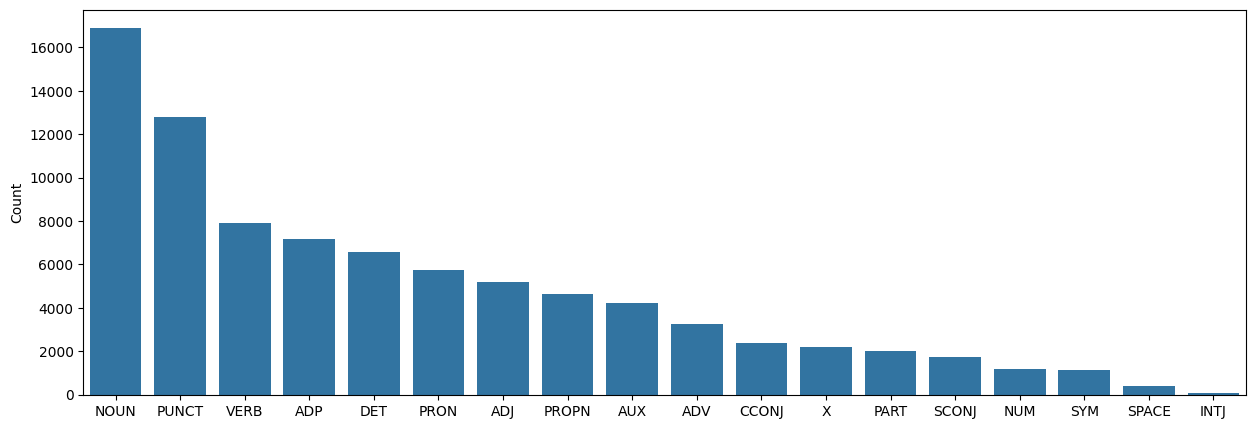

In [90]:
plt.figure(figsize=(15, 5))
plt.xlabel(" ")
sns.barplot(pos_df, x="label", y="Count")
plt.savefig("PoS_Barplot.png")

In [126]:
# Full run
dirs = ["/_books", "/_fun", "/_life", "/_work"]

data = []

for path in dirs:
    for file in os.listdir(".." + path):
        if not (file.endswith(".md")): continue
        with open(".." + path + "/" + file, "r") as f:
                print(file)
                lines = f.read().splitlines()
                sentences = [sentence.strip() for line in lines for sentence in re.split(pattern,line)]
                for sentence in sentences:
                    doc = nlp(sentence)
                    for token in doc:
                        data.append((token, token.pos_, path))


2024-07-30-et-al.md
2024-08-18-fuck-your-feelings.md
2024-05-18-living-high.md
2024-07-19-what-time-is-this-place.md
2025-01-01-democratizing-innovation.md
2024-07-21-jojo.md
2025-06-30-vibecoding.md
2025-11-21-being.md
2024-06-01-the-art-of-listening.md
2024-07-17-homo-ludens.md
2024-10-19-loss.md
2025-02-22-fifth-discipline.md
2025-10-11-heideigger.md
*2024-08-24-pedagogy-of-the-opressed.md
*2024-10-19-on-earth.md
2024-08-21-analytical-readings.md
2024-10-26-absent-body.md
2024-12-27-postman.md
2026-02-22-humbug.md
2024-05-25-mans-search-for-meaning.md
2024-06-26-ways-of-seeing.md
2025-05-12-hbs.md
2024-05-21-random-walk-down-ws.md
2024-08-17-the-presentation-of-self.md
2025-02-25-worlds-in-plain-sight.md
2024-07-10-mind-self.md
2025-09-14-katabasis.md
2024-07-13-rounds.md
2025-04-09-typography.md
2025-04-13-photography.md
2024-08-30-guilty-gear-strive.md
*2025-10-20-smiling.md
2025-03-07-eternal-sunshine.md
2025-11-11.statemottos.md
2025-05-26.tv.md
2024-08-13-kind-words-2.md
2025-0

In [130]:
words_df = pd.DataFrame(data, columns=["word","pos","path"])
words_df.head(5)

,word,pos,path
0,---,PUNCT,/_books
1,date,NOUN,/_books
2,:,PUNCT,/_books
3,,SPACE,/_books
4,2024,NUM,/_books


In [290]:
pos_to_see = "AUX"
words_df["word"] = words_df["word"].apply(lambda x: str(x) if pd.notna(x) else x)
words_df["word"] = words_df["word"].apply(lambda x: x.strip().lower() if isinstance(x, str) else x)
words_df[words_df["pos"] == pos_to_see]["word"].value_counts()[:10]

word
is       1321
are       397
be        351
can       263
was       257
have      153
do        146
's        138
being     138
would     135
Name: count, dtype: int64

In [218]:
# Full run
dirs = ["/_books", "/_fun", "/_life", "/_work"]

data = []

def sentence_phrase_pairs(text):
    doc = nlp(text)
    pairs = []
    for sent in doc.sents:
        # get phrases (here: noun chunks; adapt to other phrase types)
        phrases = [chunk.text.strip() for chunk in sent.noun_chunks]
        for phrase in phrases:
            pairs.append(phrase)
    return pairs

for path in dirs:
    for file in os.listdir(".." + path):
        if not (file.endswith(".md")): continue
        with open(".." + path + "/" + file, "r") as f:
                print(file)
                lines = f.read()
                sentences = sentence_phrase_pairs(lines)
                for pair in sentences:
                    pair_pos = []
                    doc = nlp(pair)
                    for token in doc:
                        pair_pos.append(token.pos_)
                    print((" ".join(pair_pos)))
                    data.append((" ".join(pair_pos), pair, path, file))

2024-07-30-et-al.md
PUNCT SPACE NOUN
NUM SYM NUM SYM NUM SPACE NOUN
DET NOUN
NOUN
NOUN
VERB
PUNCT
NOUN SPACE NOUN
NOUN SPACE NOUN
VERB
SYM
PROPN PROPN
PRON
DET NOUN
DET NOUN NOUN
NOUN
PROPN PROPN PROPN PROPN
PRON
PRON
DET NOUN
DET NOUN
PRON
DET NOUN ADJ NOUN
PRON
DET NUM PUNCT NOUN NOUN
DET NOUN PUNCT VERB ADJ PUNCT NOUN NOUN
PRON
DET NOUN
PUNCT ADJ ADJ NOUN PUNCT PUNCT NOUN
SCONJ
ADJ NOUN
DET ADJ ADJ NOUN
DET ADV ADJ NOUN
PRON
PRON
PRON NOUN
DET NOUN
VERB
ADJ NOUN
PRON ADJ NOUN
DET NOUN
PRON
DET NOUN
DET PROPN NOUN
DET NOUN
DET NOUN
PRON
PRON
PRON
PRON
PRON ADJ NOUN
PRON
DET NOUN
NOUN PUNCT VERB NOUN
NOUN VERB
DET NOUN
PRON
DET PROPN
PRON PUNCT SCONJ
DET ADV ADJ NOUN
X PROPN PROPN PUNCT PROPN NOUN PUNCT PROPN PUNCT PROPN SYM NOUN SYM NOUN NOUN NOUN PUNCT NOUN NOUN NOUN PUNCT NOUN PUNCT NOUN
NOUN
NOUN PUNCT NOUN
VERB PUNCT NOUN
PROPN
NOUN
NOUN
PUNCT NOUN
PRON
DET NOUN
DET NOUN
PRON
PRON
PRON
PRON
NOUN
ADJ NOUN
PRON
DET NOUN ADV
ADJ ADJ NOUN NOUN
NOUN
VERB NOUN
PRON
NOUN
DET SPACE ADJ N

In [219]:
sentence_df = pd.DataFrame(data, columns=["pair","real_pair","path","file"])
sentence_df = sentence_df[(sentence_df["pair"] != "")]
sentence_df.head(5)

,pair,real_pair,path,file
0,PUNCT SPACE NOUN,---\ndate,/_books,2024-07-30-et-al.md
1,NUM SYM NUM SYM NUM SPACE NOUN,2024-07-30\ndescription,/_books,2024-07-30-et-al.md
2,DET NOUN,A fun,/_books,2024-07-30-et-al.md
3,NOUN,satire,/_books,2024-07-30-et-al.md
4,NOUN,title,/_books,2024-07-30-et-al.md


In [230]:
sentence_df["pair"].value_counts()[:20]

pair
PRON                              4250
DET NOUN                          3645
NOUN                              3200
DET ADJ NOUN                       926
ADJ NOUN                           751
PROPN                              711
SCONJ                              447
PRON NOUN                          440
NOUN NOUN                          371
DET NOUN NOUN                      287
VERB                               264
PROPN PROPN                        247
PUNCT                              234
SYM                                127
PROPN NOUN                         118
PRON ADJ NOUN                      115
NOUN SPACE NOUN                    111
PUNCT SPACE NOUN                   103
NUM SYM NUM SYM NUM SPACE NOUN      90
DET PROPN                           81
Name: count, dtype: int64

In [282]:
sentence_df[sentence_df["pair"].str.contains("CCONJ", na=False)]["pair"].value_counts()

pair
DET ADJ CCONJ ADJ NOUN                                      20
ADJ CCONJ ADJ NOUN                                          14
NOUN CCONJ NOUN NOUN                                         6
SYM NOUN PROPN CCONJ PROPN PROPN                             5
CCONJ NOUN                                                   5
                                                            ..
DET ADV ADJ CCONJ ADV ADJ NOUN                               1
PRON PROPN PROPN CCONJ PROPN NOUN                            1
ADJ CCONJ ADJ NOUN NOUN                                      1
DET ADJ ADJ CCONJ ADJ NOUN                                   1
PUNCT PUNCT SPACE PROPN NUM PROPN CCONJ PROPN SPACE NOUN     1
Name: count, Length: 108, dtype: int64

In [297]:
sentence_df[sentence_df["pair"].str.contains(" AUX ", na=False)]

,pair,real_pair,path,file
2027,ADV AUX DET NOUN,maybe would a friend,/_books,2024-10-19-loss.md
11713,ADV SCONJ AUX DET NOUN NOUN,So how did the market crash,/_life,2025-10-23-csgo.md
14223,PRON AUX NOUN,it's behaviour,/_work,2025-09-01-syseng.md
14293,SCONJ AUX DET NOUN NOUN,How does the Internet work,/_work,2024-08-01-roadmap.sh.md
14500,X SYM SCONJ PUNCT PRON PUNCT NOUN PUNCT AUX PU...,14kb](https://endtimes.dev/why-your-website-sh...,/_work,2025-03-26-neocities.md
17488,PART VERB CCONJ AUX ADJ PUNCT PUNCT PUNCT PUNC...,"To oversimplify and be tautological: ""***good ...",/_work,2024-08-15-software-entropy.md
17622,PART ADV AUX PUNCT VERB,Not only did *Crowdstrike,/_work,2024-07-21-how-complex-systems-fail.md
